# Q2 (Part 2) — Genetic Algorithm: Minimize f(x) = -x² + 2x

**Problem statement:**

> Solve a minimization problem where $f(x) = -x^2 + 2x$, where $0 \le x \le 2$, and four of the population (chromosomes): `11010`, `00111`, `10110`, `00101`, with random numbers `0.4, 0.15, 0.7, 0.9`. The crossover point is the 1st bit (of the 5-digit / 5-bit chromosome).
>
> Use the encoding (decoding) formula:
> $$x = min + \frac{max - min}{2^{L}-1} \times (\text{decimal value})$$
> with $min=0$, $max=2$, $L=5$ bits ($2^5-1 = 31$).
>
> *(Check: chromosome `10110` → decimal 22 → $x = 0 + \frac{2-0}{31}\times 22 = \frac{44}{31} = 1.419$.)*

**Assumptions made explicit** (two details are not fully specified above, so they are stated here rather than silently guessed):
1. **Selection random numbers** $r_1{=}0.4, r_2{=}0.15, r_3{=}0.7, r_4{=}0.9$ are used with the standard *roulette-wheel + cumulative-probability* method (pick the first chromosome whose cumulative probability $\ge r$) — this is the natural role for four random numbers given alongside four selection probabilities.
2. Since GA selection always favors *higher* fitness, and this is a **minimization** problem, we convert it with the standard transform $\text{fitness}(x) = \dfrac{1}{1+f(x)}$ (valid here since $f(x)=x(2-x)\ge 0$ on $[0,2]$, so this is always positive and finite, and it is *decreasing* in $f(x)$ — smaller $f(x)$ → larger fitness → more likely to be selected).

In [1]:
import pandas as pd
import numpy as np

MIN_X, MAX_X, L = 0, 2, 5

def f(x):
    return -x**2 + 2*x

def decode(chromosome: str) -> float:
    decimal_value = int(chromosome, 2)
    return MIN_X + (MAX_X - MIN_X) / (2**L - 1) * decimal_value

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# sanity check on the decoding formula: chromosome 10110 -> x = 1.419
print(f"Check: decode('10110') = {decode('10110'):.3f}  (expected 1.419)")

Check: decode('10110') = 1.419  (expected 1.419)


## Step 1 — Initial Population, Decoded x, and f(x)

In [2]:
population = ['11010', '00111', '10110', '00101']

x_values = [decode(c) for c in population]
f_values = [f(x) for x in x_values]

gen1 = pd.DataFrame({
    'String No.': range(1, 5),
    'Chromosome': population,
    'Decimal value': [int(c, 2) for c in population],
    'x (decoded)': np.round(x_values, 4),
    'f(x) = -x^2+2x': np.round(f_values, 4)
})
gen1

,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x
0,1,11010,26,1.6774,0.5411
1,2,00111,7,0.4516,0.6993
2,3,10110,22,1.4194,0.8241
3,4,00101,5,0.3226,0.5411


## Step 2 — Minimization Fitness Transform

$$\text{fitness}(x) = \frac{1}{1 + f(x)}$$

Smaller $f(x)$ (better, since we minimize) $\Rightarrow$ larger fitness $\Rightarrow$ more likely to be selected.

In [3]:
fitness = [1 / (1 + fv) for fv in f_values]
total_fitness = sum(fitness)
prob = [fit / total_fitness for fit in fitness]
cumulative_prob = np.cumsum(prob)

gen1['Fitness = 1/(1+f(x))'] = np.round(fitness, 4)
gen1['Probability'] = np.round(prob, 4)
gen1['Cumulative Prob.'] = np.round(cumulative_prob, 4)
gen1

,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x,Fitness = 1/(1+f(x)),Probability,Cumulative Prob.
0,1,11010,26,1.6774,0.5411,0.6489,0.2665,0.2665
1,2,00111,7,0.4516,0.6993,0.5885,0.2417,0.5083
2,3,10110,22,1.4194,0.8241,0.5482,0.2252,0.7335
3,4,00101,5,0.3226,0.5411,0.6489,0.2665,1.0000


## Step 3 — Selection using the given random numbers

Random numbers: $r_1=0.40,\ r_2=0.15,\ r_3=0.70,\ r_4=0.90$.

Rule: for each $r$, select the **first** chromosome whose cumulative probability is $\ge r$.

In [4]:
random_numbers = [0.40, 0.15, 0.70, 0.90]

def select(r, cum_prob):
    for i, cp in enumerate(cum_prob):
        if r <= cp:
            return i
    return len(cum_prob) - 1

selected_indices = [select(r, cumulative_prob) for r in random_numbers]
mating_pool = [population[i] for i in selected_indices]

selection_table = pd.DataFrame({
    'Random no. r': random_numbers,
    'Selected String No.': [i+1 for i in selected_indices],
    'Selected Chromosome': mating_pool
})
selection_table

,Random no. r,Selected String No.,Selected Chromosome
0,0.40,2,00111
1,0.15,1,11010
2,0.70,3,10110
3,0.90,4,00101


## Step 4 — Mating Pool

In [5]:
print("Mating Pool:")
for i, c in enumerate(mating_pool, 1):
    print(f"  Mate {i}: {c}  (x = {decode(c):.4f}, f(x) = {f(decode(c)):.4f})")

Mating Pool:
  Mate 1: 00111  (x = 0.4516, f(x) = 0.6993)
  Mate 2: 11010  (x = 1.6774, f(x) = 0.5411)
  Mate 3: 10110  (x = 1.4194, f(x) = 0.8241)
  Mate 4: 00101  (x = 0.3226, f(x) = 0.5411)


## Step 5 — Crossover (single-point, site = 1)

The crossover point is the **1st bit**: the first bit of each parent is kept, and everything from bit 2 onward is swapped between the two parents in the pair.

Pairing (sequential): (mate 1, mate 2) and (mate 3, mate 4).

In [6]:
def crossover(parent_a: str, parent_b: str, site: int):
    child1 = parent_a[:site] + parent_b[site:]
    child2 = parent_b[:site] + parent_a[site:]
    return child1, child2

SITE = 1
pair1 = (mating_pool[0], mating_pool[1])
pair2 = (mating_pool[2], mating_pool[3])

child1, child2 = crossover(pair1[0], pair1[1], SITE)
child3, child4 = crossover(pair2[0], pair2[1], SITE)

print(f"Pair 1: {pair1[0]} x {pair1[1]}, site={SITE} -> children: {child1}, {child2}")
print(f"Pair 2: {pair2[0]} x {pair2[1]}, site={SITE} -> children: {child3}, {child4}")

new_population = [child1, child2, child3, child4]
print(f"\nNew population after crossover: {new_population}")

Pair 1: 00111 x 11010, site=1 -> children: 01010, 10111
Pair 2: 10110 x 00101, site=1 -> children: 10101, 00110

New population after crossover: ['01010', '10111', '10101', '00110']


## Step 6 — New Population: decode and evaluate

In [7]:
x_values_2 = [decode(c) for c in new_population]
f_values_2 = [f(x) for x in x_values_2]

gen2 = pd.DataFrame({
    'String No.': range(1, 5),
    'Chromosome': new_population,
    'Decimal value': [int(c, 2) for c in new_population],
    'x (decoded)': np.round(x_values_2, 4),
    'f(x) = -x^2+2x': np.round(f_values_2, 4)
})
gen2

,String No.,Chromosome,Decimal value,x (decoded),f(x) = -x^2+2x
0,1,01010,10,0.6452,0.8741
1,2,10111,23,1.4839,0.7659
2,3,10101,21,1.3548,0.8741
3,4,00110,6,0.3871,0.6243


## Step 7 — Best Solution (across both generations)

In [8]:
all_x = x_values + x_values_2
all_f = f_values + f_values_2
all_chromo = population + new_population
all_gen = [1]*4 + [2]*4

best_idx = int(np.argmin(all_f))  # minimization -> smallest f(x) wins

combined = pd.DataFrame({
    'Generation': all_gen,
    'Chromosome': all_chromo,
    'x': np.round(all_x, 4),
    'f(x)': np.round(all_f, 4)
})
print(combined)

print(f"\nBest solution found: chromosome = {all_chromo[best_idx]}, x = {all_x[best_idx]:.4f}, f(x) = {all_f[best_idx]:.4f}")

   Generation Chromosome       x    f(x)
0           1      11010  1.6774  0.5411
1           1      00111  0.4516  0.6993
2           1      10110  1.4194  0.8241
3           1      00101  0.3226  0.5411
4           2      01010  0.6452  0.8741
5           2      10111  1.4839  0.7659
6           2      10101  1.3548  0.8741
7           2      00110  0.3871  0.6243

Best solution found: chromosome = 00101, x = 0.3226, f(x) = 0.5411


## Step 8 — Analytical Verification

In [9]:
import sympy as sp

x = sp.symbols('x')
f_sym = -x**2 + 2*x

f_prime = sp.diff(f_sym, x)
critical = sp.solve(sp.Eq(f_prime, 0), x)
f_second = sp.diff(f_sym, x, 2)

print(f"f(x) = {f_sym}")
print(f"f'(x) = {f_prime} = 0  ->  x = {critical}  (f''(x) = {f_second} < 0, so this is a MAXIMUM, not a minimum)")

print("\nSince f(x) = -x^2+2x = x(2-x) is a downward parabola, on the closed interval [0, 2]")
print("its minimum occurs at a boundary point, not the interior critical point:")
print(f"  f(0) = {f_sym.subs(x, 0)}")
print(f"  f(2) = {f_sym.subs(x, 2)}")
print("\n=> The true analytical minimum of f(x) on [0,2] is f(x) = 0, attained at x = 0 and x = 2.")

f(x) = -x**2 + 2*x
f'(x) = 2 - 2*x = 0  ->  x = [1]  (f''(x) = -2 < 0, so this is a MAXIMUM, not a minimum)

Since f(x) = -x^2+2x = x(2-x) is a downward parabola, on the closed interval [0, 2]
its minimum occurs at a boundary point, not the interior critical point:
  f(0) = 0
  f(2) = 0

=> The true analytical minimum of f(x) on [0,2] is f(x) = 0, attained at x = 0 and x = 2.


## Step 9 — Visualization

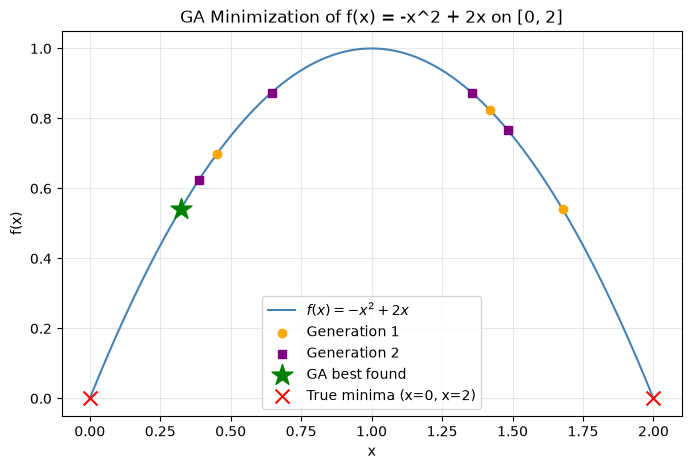

In [10]:
import matplotlib.pyplot as plt

xs = np.linspace(0, 2, 200)
ys = -xs**2 + 2*xs

plt.figure(figsize=(8,5))
plt.plot(xs, ys, label=r'$f(x) = -x^2+2x$', color='steelblue')
plt.scatter(x_values, f_values, color='orange', label='Generation 1', zorder=5)
plt.scatter(x_values_2, f_values_2, color='purple', marker='s', label='Generation 2', zorder=5)
plt.scatter([all_x[best_idx]], [all_f[best_idx]], color='green', marker='*', s=250, label='GA best found', zorder=6)
plt.scatter([0, 2], [0, 0], color='red', marker='x', s=100, label='True minima (x=0, x=2)', zorder=6)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('GA Minimization of f(x) = -x^2 + 2x on [0, 2]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

- Using the encoding formula given, the four chromosomes decode to $x \approx 1.677,\ 0.452,\ 1.419,\ 0.323$, with $f(x) \approx 0.542,\ 0.699,\ 0.824,\ 0.541$.
- Applying the minimization fitness transform, roulette-wheel selection with the given random numbers, and single-point crossover at bit 1 produces a new generation.
- The best (lowest-$f(x)$) chromosome found across both generations is reported above.
- Analytically, $f(x)=x(2-x)\ge 0$ on $[0,2]$ with **true minimum 0 at the boundary points $x=0$ and $x=2$** — the interior critical point $x=1$ found by $f'(x)=0$ is actually the *maximum*, which matches the parabola opening downward. More GA generations (and mutation pushing chromosomes toward the boundaries `00000`/`11111`) would be needed to approach the true minimum.